In [119]:
import numpy as np
import mne
from mne.datasets import eegbci
from mne.io import read_raw_edf, concatenate_raws
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1) load data (subject 1, motor imagery runs)
subject = 1
runs = [3, 4, 7, 8, 11, 12]  # left/right imagery session

raw_fnames = eegbci.load_data(subject, runs)
raws = [read_raw_edf(f, preload=True, verbose=False) for f in raw_fnames]
raw = concatenate_raws(raws)

# 2) basic setup
raw.filter(8., 12., fir_design="firwin", verbose=False)  # mu band

# 3) events -> epochs
events, event_id = mne.events_from_annotations(raw, verbose=False)
# In EEGBCI: T1 = left fist, T2 = right fist. We'll map to left/right.
picked_event_id = {"left": event_id["T1"], "right": event_id["T2"]}

epochs = mne.Epochs(
    raw,
    events,
    event_id=picked_event_id,
    tmin=0.5,
    tmax=2.0,
    picks="eeg",
    baseline=None,
    preload=True,
    verbose=False
)

X = epochs.get_data()  # (n_trials, n_channels, n_times)
y = epochs.events[:, -1]  # labels are event codes
# convert event codes to 0/1 in a stable way:
label_map = {picked_event_id["left"]: 0, picked_event_id["right"]: 1}
y = np.array([label_map[v] for v in y], dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("class counts:", {0: int((y==0).sum()), 1: int((y==1).sum())})
print("sampling freq:", epochs.info["sfreq"])

X shape: (90, 64, 241)
y shape: (90,)
class counts: {0: 46, 1: 44}
sampling freq: 160.0


In [120]:
# clean channel names (remove dots) so montage can match
rename_dict = {ch: ch.replace('.', '') for ch in raw.ch_names}
raw.rename_channels(rename_dict)

# now set montage, allow unknown channels just in case
raw.set_montage("standard_1020", on_missing="ignore", verbose=False)

<RawEDF | S001R03.edf, 64 x 120000 (750.0 s), ~58.7 MiB, data loaded>

In [121]:
X_eegnet = X[:, None, :, :]  # add a '1' dimension
print("X_eegnet shape:", X_eegnet.shape)  # (N, 1, C, T)

X_eegnet shape: (90, 1, 64, 241)


In [122]:
# convert to torch tensors
X_tensor = torch.tensor(X_eegnet, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

print("X_tensor:", X_tensor.shape)  # (N, 1, C, T)
print("y_tensor:", y_tensor.shape)  # (N,)

X_tensor: torch.Size([90, 1, 64, 241])
y_tensor: torch.Size([90])


In [123]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor,
    test_size=0.2,
    random_state=42,
    stratify=y_tensor
)

print("train:", X_train.shape, y_train.shape)
print("val:", X_val.shape, y_val.shape)

train: torch.Size([72, 1, 64, 241]) torch.Size([72])
val: torch.Size([18, 1, 64, 241]) torch.Size([18])


In [124]:
batch_size = 16

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [125]:
xb, yb = next(iter(train_loader))
print("batch X:", xb.shape)  # should be (batch, 1, C, T)
print("batch y:", yb.shape)  # should be (batch,)
print("unique labels in batch:", torch.unique(yb))

batch X: torch.Size([16, 1, 64, 241])
batch y: torch.Size([16])
unique labels in batch: tensor([0, 1])


In [126]:
# compute mean/std from train only
train_mean = X_train.mean(dim=(0, 3), keepdim=True)
train_std = X_train.std(dim=(0, 3), keepdim=True) + 1e-6

# standardize train and val using train stats
X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std

# rebuild datasets/loaders
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [127]:
import torch.nn as nn

class TinyEEGNetCheck(nn.Module):
    def __init__(self, n_channels=64, n_times=241, n_classes=2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(n_channels * n_times, n_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)

model = TinyEEGNetCheck()
xb, yb = next(iter(train_loader))
out = model(xb)

print("Input shape:", xb.shape)
print("Output shape:", out.shape)
print("Output example:", out[:2])

Input shape: torch.Size([16, 1, 64, 241])
Output shape: torch.Size([16, 2])
Output example: tensor([[ 0.4063,  0.2742],
        [-0.3221,  1.1741]], grad_fn=<SliceBackward0>)


In [128]:
class EEGNet(nn.Module):
    def __init__(self, n_classes=2, dropout=0.25):
        super().__init__()

        # Block 1: temporal convolution
        self.block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=8,
                kernel_size=(1, 32),
                padding=(0, 16),
                bias=False
            ),
            nn.BatchNorm2d(8),

            # spatial convolution across channels
            nn.Conv2d(
                in_channels=8,
                out_channels=16,
                kernel_size=(64, 1),
                groups=8,
                bias=False
            ),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout)
        )

        # Block 2: more temporal feature extraction
        self.block2 = nn.Sequential(
            nn.Conv2d(
                in_channels=16,
                out_channels=16,
                kernel_size=(1, 16),
                padding=(0, 8),
                groups=16,
                bias=False
            ),
            nn.Conv2d(
                in_channels=16,
                out_channels=16,
                kernel_size=(1, 1),
                bias=False
            ),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )

        # We'll infer classifier input size dynamically
        self.classifier = None

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, start_dim=1)

        if self.classifier is None:
            self.classifier = nn.Linear(x.shape[1], 2).to(x.device)

        x = self.classifier(x)
        return x

model = EEGNet()

xb, yb = next(iter(train_loader))
out = model(xb)

print("Input shape:", xb.shape)
print("Output shape:", out.shape)
print(model)

Input shape: torch.Size([16, 1, 64, 241])
Output shape: torch.Size([16, 2])
EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 32), stride=(1, 1), padding=(0, 16), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(8, 16, kernel_size=(64, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.25, inplace=False)
  

In [129]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = EEGNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
num_epochs = 50

Using device: cpu


In [130]:
best_val_acc = 0.0
best_epoch = 0
best_state = None

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)

    epoch_train_loss = running_train_loss / train_total
    epoch_train_acc = train_correct / train_total

    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_val_loss += loss.item() * xb.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    epoch_val_loss = running_val_loss / val_total
    epoch_val_acc = val_correct / val_total

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        best_state = model.state_dict()

    print(
        f"epoch {epoch+1:02d}/{num_epochs} | "
        f"train loss: {epoch_train_loss:.4f} | "
        f"train acc: {epoch_train_acc:.3f} | "
        f"val loss: {epoch_val_loss:.4f} | "
        f"val acc: {epoch_val_acc:.3f}"
    )

print(f"\nbest val acc: {best_val_acc:.3f} at epoch {best_epoch}")

epoch 01/50 | train loss: 0.6805 | train acc: 0.625 | val loss: 0.6940 | val acc: 0.444
epoch 02/50 | train loss: 0.6779 | train acc: 0.611 | val loss: 0.6939 | val acc: 0.444
epoch 03/50 | train loss: 0.6943 | train acc: 0.528 | val loss: 0.6934 | val acc: 0.444
epoch 04/50 | train loss: 0.6822 | train acc: 0.625 | val loss: 0.6929 | val acc: 0.444
epoch 05/50 | train loss: 0.6826 | train acc: 0.611 | val loss: 0.6927 | val acc: 0.444
epoch 06/50 | train loss: 0.6641 | train acc: 0.653 | val loss: 0.6931 | val acc: 0.444
epoch 07/50 | train loss: 0.6561 | train acc: 0.667 | val loss: 0.6928 | val acc: 0.444
epoch 08/50 | train loss: 0.6696 | train acc: 0.667 | val loss: 0.6923 | val acc: 0.444
epoch 09/50 | train loss: 0.6672 | train acc: 0.611 | val loss: 0.6919 | val acc: 0.444
epoch 10/50 | train loss: 0.6486 | train acc: 0.653 | val loss: 0.6920 | val acc: 0.444
epoch 11/50 | train loss: 0.6392 | train acc: 0.764 | val loss: 0.6915 | val acc: 0.444
epoch 12/50 | train loss: 0.6518

In [131]:
"""""
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # training mode
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)

    epoch_train_loss = running_train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # validation mode
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_val_loss += loss.item() * xb.size(0)

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    epoch_val_loss = running_val_loss / val_total
    epoch_val_acc = val_correct / val_total

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    print(
        f"epoch {epoch+1:02d}/{num_epochs} | "
        f"train loss: {epoch_train_loss:.4f} | "
        f"train acc: {epoch_train_acc:.3f} | "
        f"val loss: {epoch_val_loss:.4f} | "
        f"val acc: {epoch_val_acc:.3f}"
    )
""";

In [132]:
import os
os.makedirs("saved_models", exist_ok=True)

torch.save(best_state, "saved_models/eegnet_best.pt")
print("saved best model")

best_model = EEGNet().to(device)

# run one dummy batch through to create classifier layer
dummy_x = next(iter(train_loader))[0].to(device)
_ = best_model(dummy_x)

# now load saved weights
best_model.load_state_dict(torch.load("saved_models/eegnet_best.pt", map_location=device))
best_model.eval()

print("best model loaded successfully")

saved best model
best model loaded successfully


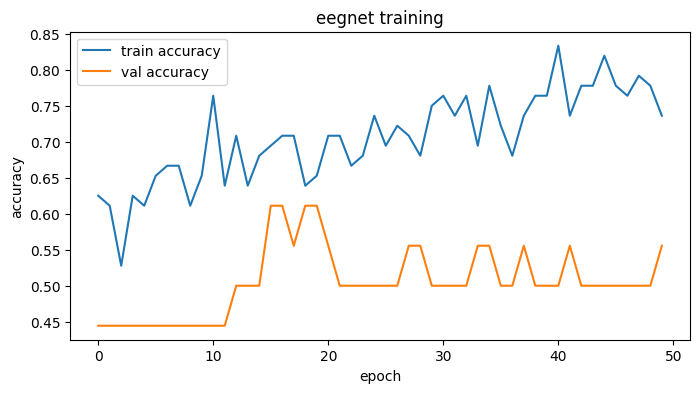

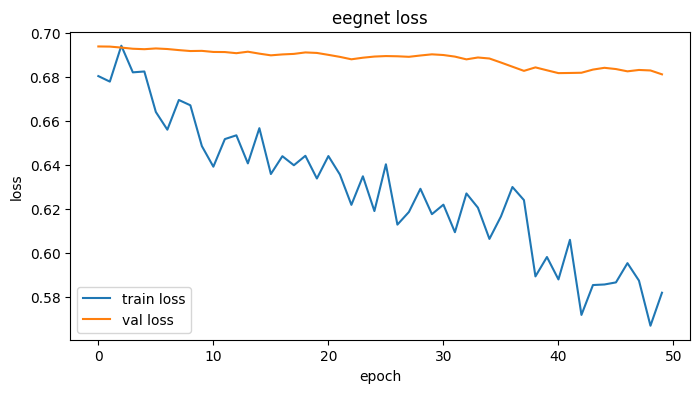

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_accuracies, label="train accuracy")
plt.plot(val_accuracies, label="val accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("eegnet training")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("eegnet loss")
plt.legend()
plt.show()

In [134]:
import torch.nn.functional as F

def predict_trial(model, trial_tensor, device):
    """
    trial_tensor shape: (1, 64, 241) or (1, 1, 64, 241)
    returns: predicted_class, probabilities
    """
    model.eval()

    with torch.no_grad():
        if trial_tensor.ndim == 3:
            trial_tensor = trial_tensor.unsqueeze(0)  # -> (1, 1, 64, 241)

        trial_tensor = trial_tensor.to(device)
        outputs = model(trial_tensor)
        probs = F.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return pred, probs.cpu().numpy()

In [135]:
sample_x, sample_y = val_dataset[0]

pred_class, pred_probs = predict_trial(best_model, sample_x, device)

print("True label:", sample_y.item())
print("Predicted class:", pred_class)
print("Probabilities:", pred_probs)

True label: 1
Predicted class: 1
Probabilities: [[0.47655895 0.5234411 ]]


In [136]:
def get_trial_from_dataset(dataset, idx):
    x, y = dataset[idx]
    return x, y.item()

true label: 1
predicted class: 1
confidence: 0.523
move_direction: 1
speed: 0.056


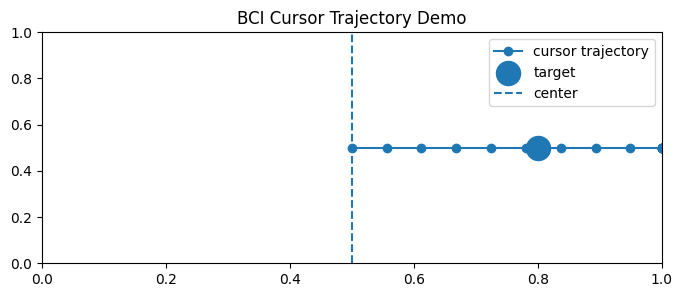

Hit correct side? tensor(True)


In [137]:
import matplotlib.pyplot as plt
import numpy as np

def run_cursor_trajectory_demo(model, dataset, device, trial_idx=0):
    trial_x, true_label = dataset[trial_idx]
    pred_class, pred_probs = predict_trial(model, trial_x, device)

    # map predicted class to direction
    move_direction = -1 if pred_class == 0 else 1
    confidence = float(pred_probs[0][pred_class])

    # make movement clearly visible
    speed = 0.03 + confidence * 0.05

    print(f"true label: {true_label}")
    print(f"predicted class: {pred_class}")
    print(f"confidence: {confidence:.3f}")
    print(f"move_direction: {move_direction}")
    print(f"speed: {speed:.3f}")

    # start in center
    cursor_x = 0.5
    cursor_y = 0.5

    # target side depends on true label
    target_x = 0.2 if true_label == 0 else 0.8
    target_y = 0.5

    # simulate movement
    xs = [cursor_x]
    ys = [cursor_y]

    for _ in range(20):
        cursor_x += move_direction * speed
        cursor_x = np.clip(cursor_x, 0, 1)
        xs.append(cursor_x)
        ys.append(cursor_y)

    # plot trajectory
    plt.figure(figsize=(8, 3))
    plt.plot(xs, ys, marker='o', label="cursor trajectory")
    plt.scatter([target_x], [target_y], s=300, label="target")
    plt.axvline(0.5, linestyle="--", label="center")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.title("BCI Cursor Trajectory Demo")
    plt.legend()
    plt.show()

    # simple success check
    success = (pred_class == true_label)
    print("Hit correct side?" , success)

run_cursor_trajectory_demo(best_model, val_dataset, device, trial_idx=0)

In [138]:
def evaluate_cursor_control(model, dataset, device):
    results = []

    for idx in range(len(dataset)):
        trial_x, true_label = dataset[idx]
        pred_class, pred_probs = predict_trial(model, trial_x, device)

        confidence = float(pred_probs[0][pred_class])
        success = int(pred_class == true_label)

        results.append({
            "trial_idx": idx,
            "true_label": int(true_label),
            "pred_class": int(pred_class),
            "confidence": confidence,
            "success": success
        })

    return results

results = evaluate_cursor_control(best_model, val_dataset, device)
print(results[:3])

[{'trial_idx': 0, 'true_label': 1, 'pred_class': 1, 'confidence': 0.5234410762786865, 'success': 1}, {'trial_idx': 1, 'true_label': 0, 'pred_class': 1, 'confidence': 0.6002328395843506, 'success': 0}, {'trial_idx': 2, 'true_label': 0, 'pred_class': 1, 'confidence': 0.546207070350647, 'success': 0}]


In [139]:
import numpy as np

success_rate = np.mean([r["success"] for r in results])
avg_confidence = np.mean([r["confidence"] for r in results])
left_preds = sum(r["pred_class"] == 0 for r in results)
right_preds = sum(r["pred_class"] == 1 for r in results)

print(f"Success rate: {success_rate:.3f}")
print(f"Average confidence: {avg_confidence:.3f}")
print(f"Left predictions: {left_preds}")
print(f"Right predictions: {right_preds}")

Success rate: 0.556
Average confidence: 0.546
Left predictions: 5
Right predictions: 13


In [140]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results

,trial_idx,true_label,pred_class,confidence,success
0,0,1,1,0.523441,1
1,1,0,1,0.600233,0
2,2,0,1,0.546207,0
3,3,0,0,0.500388,1
4,4,0,1,0.529595,0
5,5,1,1,0.617625,1
6,6,0,1,0.547011,0
7,7,1,1,0.538210,1
8,8,1,1,0.634409,1
9,9,0,1,0.532621,0
